<a href="https://colab.research.google.com/github/MDsamiulalim-gig/-WT-summer-24-25/blob/main/Cnn_23-50151-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving archive (1).zip to archive (1).zip


In [3]:
!ls


'archive (1).zip'   sample_data


In [4]:
!unzip "archive (1).zip"

Streaming output truncated to the last 5000 lines.
  inflating: cifar10/train/truck/0001.png  
  inflating: cifar10/train/truck/0002.png  
  inflating: cifar10/train/truck/0003.png  
  inflating: cifar10/train/truck/0004.png  
  inflating: cifar10/train/truck/0005.png  
  inflating: cifar10/train/truck/0006.png  
  inflating: cifar10/train/truck/0007.png  
  inflating: cifar10/train/truck/0008.png  
  inflating: cifar10/train/truck/0009.png  
  inflating: cifar10/train/truck/0010.png  
  inflating: cifar10/train/truck/0011.png  
  inflating: cifar10/train/truck/0012.png  
  inflating: cifar10/train/truck/0013.png  
  inflating: cifar10/train/truck/0014.png  
  inflating: cifar10/train/truck/0015.png  
  inflating: cifar10/train/truck/0016.png  
  inflating: cifar10/train/truck/0017.png  
  inflating: cifar10/train/truck/0018.png  
  inflating: cifar10/train/truck/0019.png  
  inflating: cifar10/train/truck/0020.png  
  inflating: cifar10/train/truck/0021.png  
  inflating: cifar10/trai

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [16]:
data_dir = "/content/drive/MyDrive/archive (1)"   # your unzipped folder

train_dir = f"{data_dir}/train"
val_dir   = f"{data_dir}/val"

In [22]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train_dir = "/content/drive/MyDrive/CVPR/data/train"
test_dir  = "/content/drive/MyDrive/CVPR/data/test"

In [23]:
import os

for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

In [24]:
import shutil

# Move train images
for file in os.listdir(train_dir):
    for cls in classes:
        if file.startswith(cls):
            shutil.move(os.path.join(train_dir, file), os.path.join(train_dir, cls))
            break

# Move test images
for file in os.listdir(test_dir):
    for cls in classes:
        if file.startswith(cls):
            shutil.move(os.path.join(test_dir, file), os.path.join(test_dir, cls))
            break

In [28]:
#CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3, 16, 3),   # Convolution layer
            nn.ReLU(),             # Activation
            nn.MaxPool2d(2),       # Pooling

            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Linear(32*30*30, 128),  # Fully connected
            nn.ReLU(),
            nn.Linear(128, 2)          # Output layer (2 classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = SimpleCNN()


In [29]:
#CNN improve module
class CNN_Improved(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3, 16, 3),
            nn.BatchNorm2d(16),   # Normalize features
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Linear(32*30*30, 128),
            nn.ReLU(),
            nn.Dropout(0.5),      # Prevent overfitting
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = CNN_Improved()

In [30]:
#summary
!pip install torchsummary
from torchsummary import summary

summary(model, (3,128,128))  # Show architecture

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 126, 126]             448
       BatchNorm2d-2         [-1, 16, 126, 126]              32
              ReLU-3         [-1, 16, 126, 126]               0
         MaxPool2d-4           [-1, 16, 63, 63]               0
            Conv2d-5           [-1, 32, 61, 61]           4,640
       BatchNorm2d-6           [-1, 32, 61, 61]              64
              ReLU-7           [-1, 32, 61, 61]               0
         MaxPool2d-8           [-1, 32, 30, 30]               0
            Linear-9                  [-1, 128]       3,686,528
             ReLU-10                  [-1, 128]               0
          Dropout-11                  [-1, 128]               0
           Linear-12                    [-1, 2]             258
Total params: 3,691,970
Trainable params: 3,691,970
Non-trainable params: 0
---------------------------

In [31]:

#training srtup
criterion = nn.CrossEntropyLoss()   # Multi-class loss
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Optimizer

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.1)  # Learning rate decay

In [34]:
import torch

# Assuming your model, train_loader, val_loader are already defined
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

num_epochs = 5

for epoch in range(num_epochs):
    # ---- Training Accuracy ----
    model.train()
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_accuracy = correct / total
    print(f"Epoch {epoch+1} - Train Accuracy: {train_accuracy:.4f}")

    # ---- Validation Accuracy ----
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_accuracy = correct / total
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.4f}\n")

NameError: name 'train_loader' is not defined

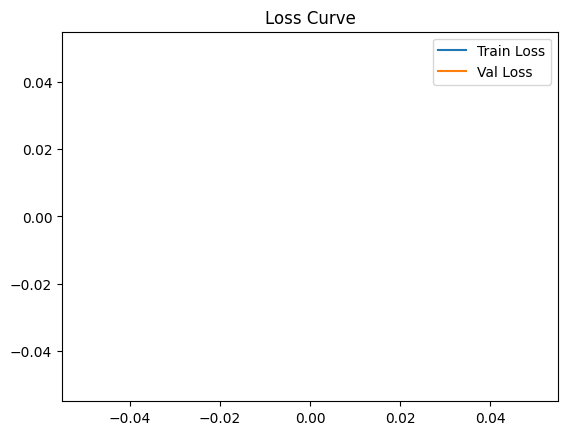

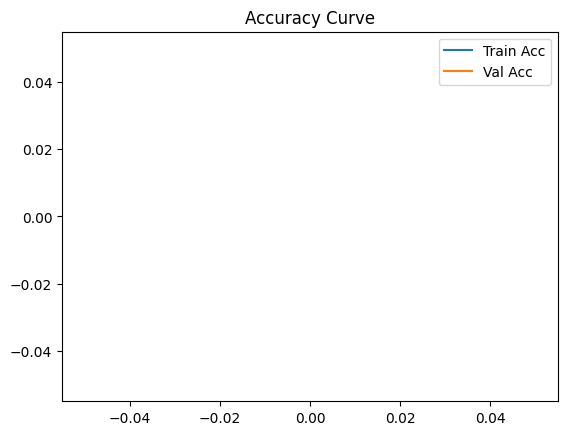

In [35]:
#loss graph
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [36]:
#confusion mattrix
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

NameError: name 'val_loader' is not defined

In [37]:
print(classification_report(all_labels, all_preds))

ValueError: max() iterable argument is empty

In [38]:

torch.save(model.state_dict(), "cnn_model.pth")  # Saved weights